Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 136s 341ms/step - accuracy: 0.8019 - loss: 0.4261 - val_accuracy: 0.8578 - val_loss: 0.3444
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 117s 300ms/step - accuracy: 0.8873 - loss: 0.2822 - val_accuracy: 0.8735 - val_loss: 0.3132
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 297ms/step - accuracy: 0.9103 - loss: 0.2271 - val_accuracy: 0.8592 - val_loss: 0.3308


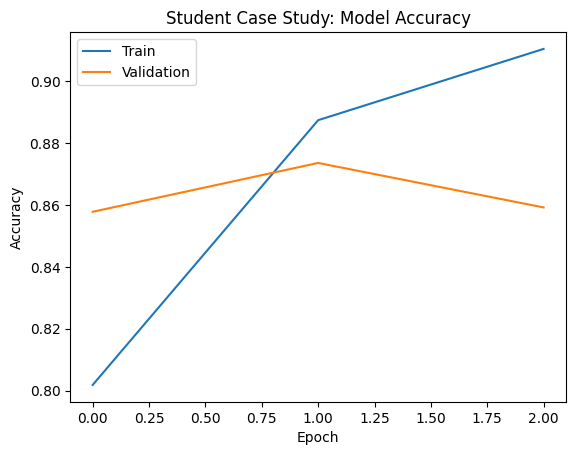

In [9]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# 1. Load Data (Top 5000 words only)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

# 2. Preprocessing (Make every review exactly 200 words)
x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)

# 3. Build Model
model = Sequential([
    Embedding(5000, 128, input_length=200), # Turns numbers into word vectors
    LSTM(64),                               # The 'memory' layer
    Dense(1, activation='sigmoid')          # Output: 0 (Neg) to 1 (Pos)
])

# 4. Compile & Train
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=3, batch_size=64, validation_data=(x_test, y_test))

# 5. Visualize Results
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Student Case Study: Model Accuracy')
plt.ylabel('Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.show()